In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
os.makedirs("../reports/figures", exist_ok=True)
FIG_DIR = "../reports/figures"
print("Figures will be saved to:", FIG_DIR)


Figures will be saved to: ../reports/figures


In [4]:
# Load the artifacts saved in the training notebook
tfidf       = joblib.load("../models/tfidf_vectorizer.pkl")
lr_model    = joblib.load("../models/logistic_regression.pkl")
rf_model    = joblib.load("../models/random_forest.pkl")

print("✅ Models loaded")
print("TF-IDF vocabulary size:", len(tfidf.get_feature_names_out()))


✅ Models loaded
TF-IDF vocabulary size: 100000


In [5]:
df = pd.read_csv("../data/processed_data/clean_news_data.csv")
df = df.dropna(subset=["clean_text", "label"]).reset_index(drop=True)
df["clean_text"] = df["clean_text"].astype(str)

print("Shape:", df.shape)
print(df.head(3))

Shape: (38322, 2)
                                          clean_text  label
0  lebanon army chief warns of israel threat amid...      1
1  in schools and hospitals turkey carves north s...      1
2  yikes academy award winning actor starring in ...      0


In [6]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Transform using the SAVED vectorizer (do NOT fit again!)
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)

Train shape: (30657, 100000)
Test shape : (7665, 100000)


## 1. SHAP for Logistic Regression (LinearExplainer)

Logistic Regression is a linear model, so SHAP is exact and fast.
We use a background sample of the training set to compute the expected value.


In [7]:
# Background sample — 500 rows is enough and keeps it fast
background = shap.sample(X_train_tfidf, 100, random_state=RANDOM_STATE)

explainer_lr = shap.LinearExplainer(
    lr_model,
    background,
    feature_names=tfidf.get_feature_names_out()
)

print("✅ LinearExplainer ready")

✅ LinearExplainer ready


In [8]:
# SHAP on the full 9,000 rows is slow. Use 500 random rows.
sample_size = 500
X_test_sample = X_test_tfidf[:sample_size]
y_test_sample = y_test.iloc[:sample_size].reset_index(drop=True)

shap_values_lr = explainer_lr.shap_values(X_test_sample)
print("SHAP values shape:", shap_values_lr.shape)

SHAP values shape: (500, 100000)


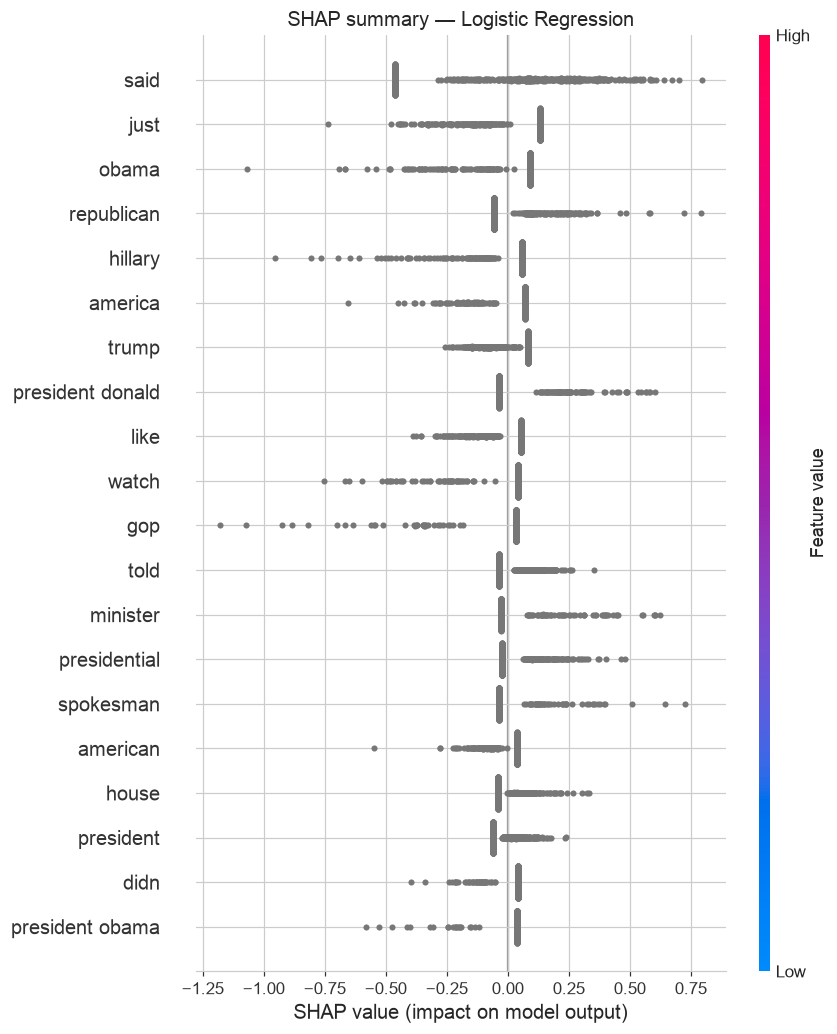

In [9]:
plt.figure()
shap.summary_plot(
    shap_values_lr,
    X_test_sample,
    feature_names=tfidf.get_feature_names_out(),
    max_display=20,
    show=False
)
plt.title("SHAP summary — Logistic Regression", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_summary_lr.png", dpi=150, bbox_inches="tight")
plt.show()

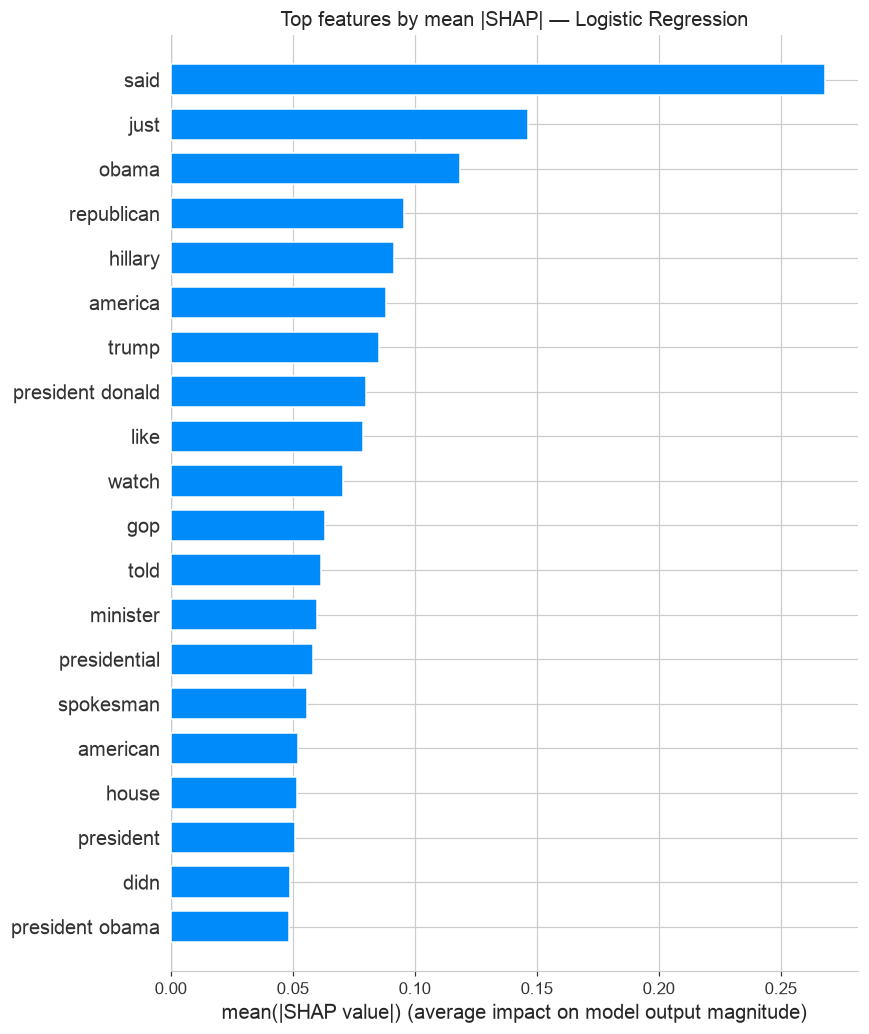

In [10]:
plt.figure()
shap.summary_plot(
    shap_values_lr,
    X_test_sample,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top features by mean |SHAP| — Logistic Regression", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_bar_lr.png", dpi=150, bbox_inches="tight")
plt.show()

Article (first 300 chars):
watch unhinged clinton supporter knocks elderly man to ground after he tries to stop him from burning u s flag hillary s lawless anti american supporters were clearly just trying to promote that unity she spoke of during her brilliant dnc speech police say that a clinton supporter lit a flag on fire ...

Actual   : FAKE
Predicted: FAKE


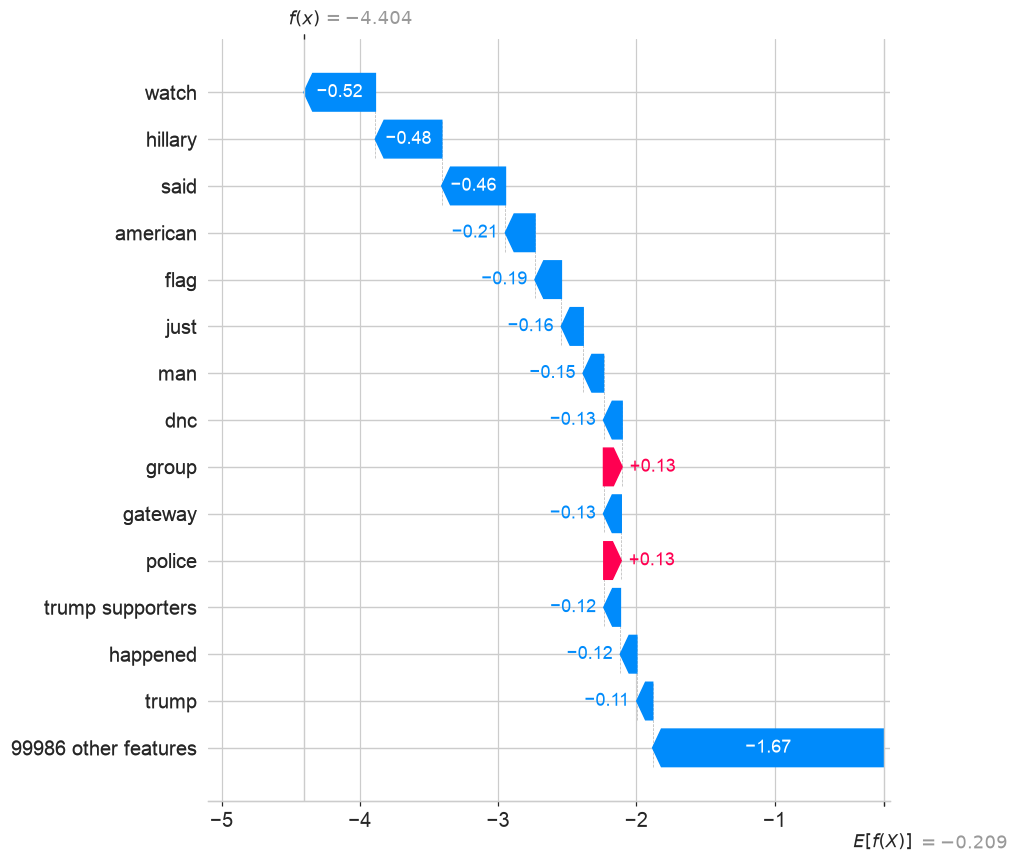

In [11]:
idx = 0  # change this to inspect different articles

article = X_test.iloc[idx]
actual  = y_test.iloc[idx]
pred    = lr_model.predict(X_test_tfidf[idx])[0]

print("Article (first 300 chars):")
print(article[:300], "...\n")
print("Actual   :", "FAKE" if actual == 0 else "REAL")
print("Predicted:", "FAKE" if pred == 0 else "REAL")

shap.plots._waterfall.waterfall_legacy(
    explainer_lr.expected_value,
    shap_values_lr[idx],
    feature_names=tfidf.get_feature_names_out(),
    max_display=15
)

## 2. SHAP for Random Forest (TreeExplainer)

TreeExplainer computes exact Shapley values for tree ensembles.
We use a smaller sample because SHAP on sparse TF-IDF matrices is memory-heavy.

In [12]:
# Small dense sample for SHAP

explainer_rf = shap.TreeExplainer(rf_model)

X_test_rf_sample = X_test_tfidf[:50].toarray()

shap_values_rf = explainer_rf.shap_values(
    X_test_rf_sample,
    check_additivity=False       # 👈 REQUIRED for sparse-trained RF
)

print("Type:", type(shap_values_rf))
print("Shape:", np.array(shap_values_rf).shape)

Type: <class 'numpy.ndarray'>
Shape: (50, 100000, 2)


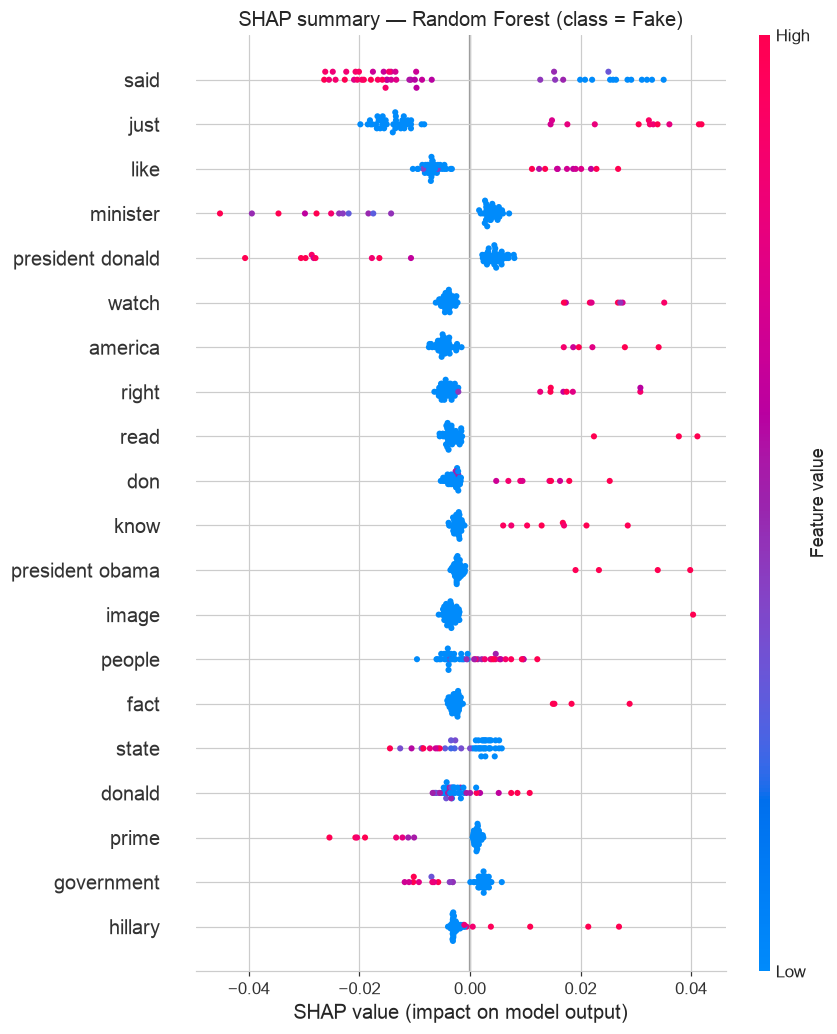

In [13]:
# Slice the Fake class
shap_values_fake = shap_values_rf[:, :, 0]

plt.figure()
shap.summary_plot(
    shap_values_fake,
    X_test_rf_sample,
    feature_names=tfidf.get_feature_names_out(),
    max_display=20,
    show=False
)
plt.title("SHAP summary — Random Forest (class = Fake)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_summary_rf.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print("Explainer type:", type(explainer_rf))
print("Explainer expected_value:", explainer_rf.expected_value)
print("Sample shape:", X_test_rf_sample.shape)
print("Sample dtype:", X_test_rf_sample.dtype)
print("Sample has NaN:", np.isnan(X_test_rf_sample).any())

Explainer type: <class 'shap.explainers._tree.TreeExplainer'>
Explainer expected_value: [0.50002218 0.49997782]
Sample shape: (50, 100000)
Sample dtype: float64
Sample has NaN: False


In [15]:
feature_names = tfidf.get_feature_names_out()
coefs = lr_model.coef_[0]                # shape: (n_features,)

# Class 0 = FAKE → most negative coefficients
top_fake_idx = np.argsort(coefs)[:20]
top_fake = pd.DataFrame({
    "word": feature_names[top_fake_idx],
    "coef": coefs[top_fake_idx]
})

# Class 1 = REAL → most positive coefficients
top_real_idx = np.argsort(coefs)[-20:][::-1]
top_real = pd.DataFrame({
    "word": feature_names[top_real_idx],
    "coef": coefs[top_real_idx]
})

print("Top 20 words → FAKE:")
print(top_fake.to_string(index=False))
print("\nTop 20 words → REAL:")
print(top_real.to_string(index=False))

Top 20 words → FAKE:
           word       coef
           just -10.782932
            gop  -9.332632
           read  -8.391571
          watch  -8.354877
          obama  -7.243294
        america  -7.148365
president trump  -7.139595
           like  -6.225219
        hillary  -6.201709
president obama  -6.110221
       breaking  -5.852862
             mr  -5.304894
           fact  -5.302051
           wire  -4.861414
            sen  -4.858143
            isn  -4.846149
            rep  -4.798884
           isis  -4.760020
           didn  -4.724519
          doesn  -4.510867

Top 20 words → REAL:
                   word      coef
                   said 21.060706
       president donald  9.821742
             republican  6.396615
               minister  5.572129
         said statement  5.503601
              spokesman  5.405472
       president barack  5.090809
           presidential  5.074189
                   told  5.011662
             trump said  4.949847
             dem

/var/folders/p4/60m358jj4yxf2zj5dk4cg0m00000gn/T/ipykernel_7810/2926799053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fake, x="coef", y="word", ax=axes[0], palette="Reds_r")
/var/folders/p4/60m358jj4yxf2zj5dk4cg0m00000gn/T/ipykernel_7810/2926799053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_real, x="coef", y="word", ax=axes[1], palette="Blues")


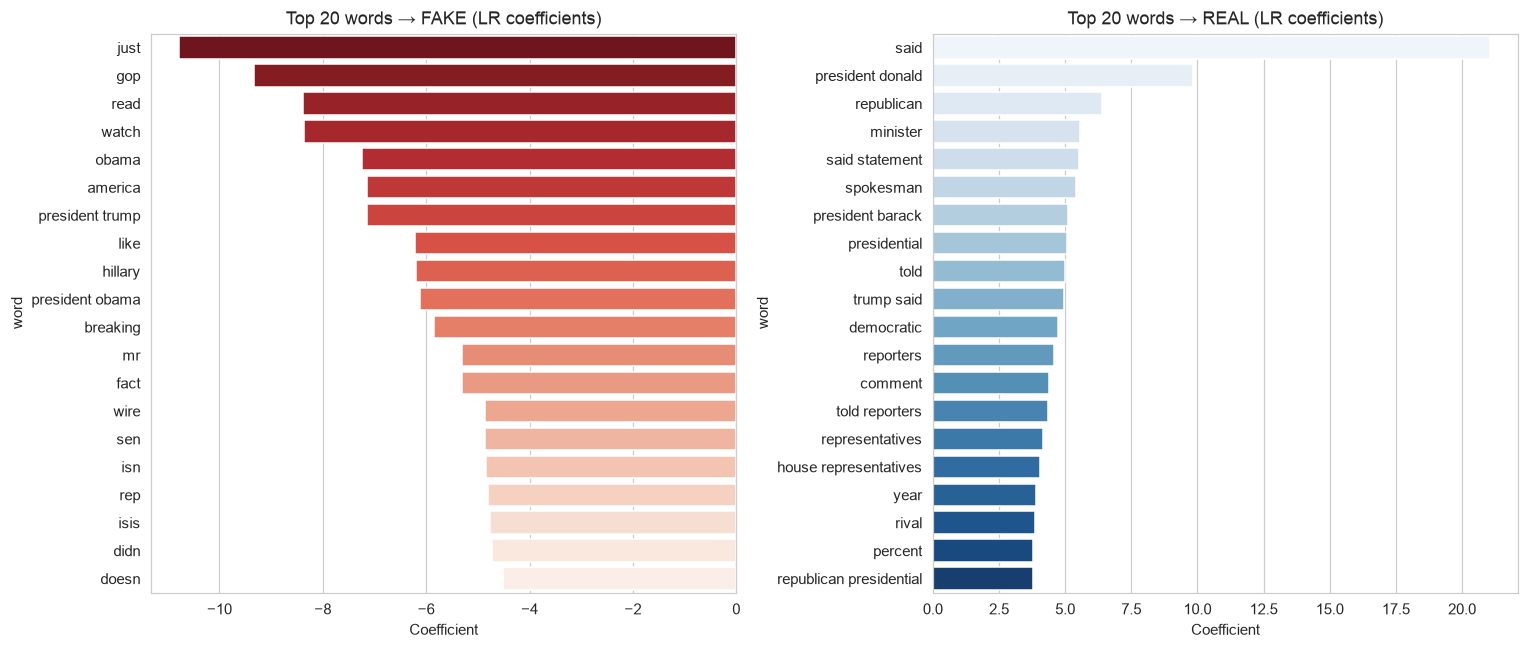

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_fake, x="coef", y="word", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top 20 words → FAKE (LR coefficients)")
axes[0].set_xlabel("Coefficient")

sns.barplot(data=top_real, x="coef", y="word", ax=axes[1], palette="Blues")
axes[1].set_title("Top 20 words → REAL (LR coefficients)")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/p4/60m358jj4yxf2zj5dk4cg0m00000gn/T/ipykernel_7810/1002130027.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rf, x="importance", y="word", palette="Greens_r")


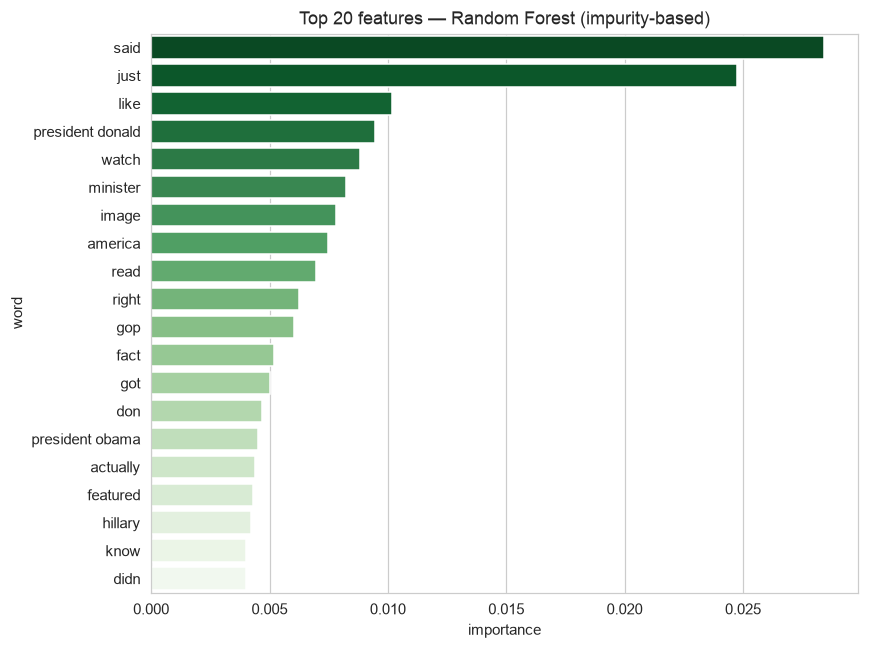

            word  importance
            said    0.028436
            just    0.024740
            like    0.010193
president donald    0.009449
           watch    0.008813
        minister    0.008247
           image    0.007808
         america    0.007474
            read    0.006962
           right    0.006228
             gop    0.006040
            fact    0.005192
             got    0.005014
             don    0.004671
 president obama    0.004524
        actually    0.004391
        featured    0.004322
         hillary    0.004234
            know    0.004011
            didn    0.004001


In [17]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:][::-1]

top_rf = pd.DataFrame({
    "word": feature_names[indices],
    "importance": importances[indices]
})

plt.figure(figsize=(8, 6))
sns.barplot(data=top_rf, x="importance", y="word", palette="Greens_r")
plt.title("Top 20 features — Random Forest (impurity-based)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(top_rf.to_string(index=False))

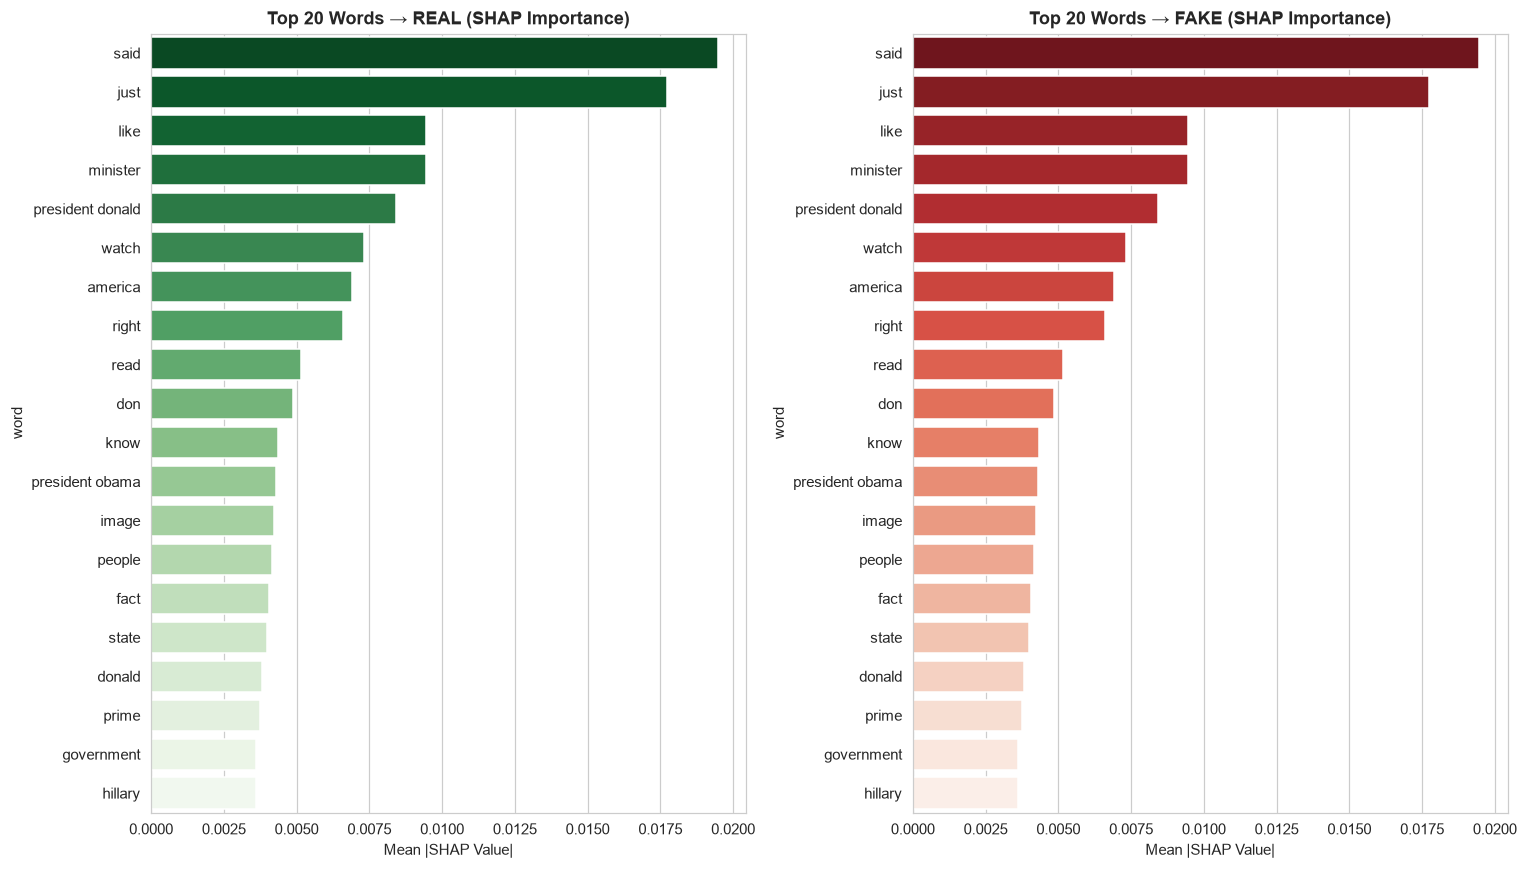

TOP REAL WORDS:
            word  importance class
            said    0.019464  Real
            just    0.017739  Real
            like    0.009462  Real
        minister    0.009439  Real
president donald    0.008419  Real
           watch    0.007324  Real
         america    0.006910  Real
           right    0.006600  Real
            read    0.005158  Real
             don    0.004863  Real
            know    0.004348  Real
 president obama    0.004288  Real
           image    0.004236  Real
          people    0.004157  Real
            fact    0.004061  Real
           state    0.003990  Real
          donald    0.003803  Real
           prime    0.003748  Real
      government    0.003614  Real
         hillary    0.003608  Real

TOP FAKE WORDS:
            word  importance class
            said    0.019464  Fake
            just    0.017739  Fake
            like    0.009462  Fake
        minister    0.009439  Fake
president donald    0.008419  Fake
           watch    0.

In [18]:
# Handle both 3D ndarray (samples, features, classes) and list formats
if isinstance(shap_values_rf, list):
    shap_fake_matrix = shap_values_rf[0]
    shap_real_matrix = shap_values_rf[1]
elif hasattr(shap_values_rf, "ndim") and shap_values_rf.ndim == 3:
    shap_fake_matrix = shap_values_rf[:, :, 0]  # Class 0: Fake
    shap_real_matrix = shap_values_rf[:, :, 1]  # Class 1: Real
else:
    shap_fake_matrix = -shap_values_rf
    shap_real_matrix = shap_values_rf

# Mean absolute SHAP value across all 50 samples for each of the 100,000 features
shap_real = np.abs(shap_real_matrix).mean(axis=0)  # Shape: (100000,)
shap_fake = np.abs(shap_fake_matrix).mean(axis=0)  # Shape: (100000,)

# Top 20 for REAL
indices_real = np.argsort(shap_real)[-20:][::-1]
top_real = pd.DataFrame({
    "word": feature_names[indices_real],
    "importance": shap_real[indices_real],
    "class": "Real"
})

# Top 20 for FAKE
indices_fake = np.argsort(shap_fake)[-20:][::-1]
top_fake = pd.DataFrame({
    "word": feature_names[indices_fake],
    "importance": shap_fake[indices_fake],
    "class": "Fake"
})

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(data=top_real, x="importance", y="word", palette="Greens_r", ax=axes[0], hue="word", legend=False)
axes[0].set_title("Top 20 Words → REAL (SHAP Importance)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Mean |SHAP Value|")

sns.barplot(data=top_fake, x="importance", y="word", palette="Reds_r", ax=axes[1], hue="word", legend=False)
axes[1].set_title("Top 20 Words → FAKE (SHAP Importance)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mean |SHAP Value|")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/rf_real_vs_fake.png", dpi=150, bbox_inches="tight")
plt.show()

print("TOP REAL WORDS:")
print(top_real.to_string(index=False))
print("\nTOP FAKE WORDS:")
print(top_fake.to_string(index=False))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ DistilBERT loaded with eager attention on mps
Article #0 (Actual: FAKE)
watch unhinged clinton supporter knocks elderly man to ground after he tries to stop him from burning u s flag hillary s lawless anti american supporters were clearly just trying to promote that unity she spoke of during her brilliant dnc speech police say that a clinton supporter lit a flag on fire ...



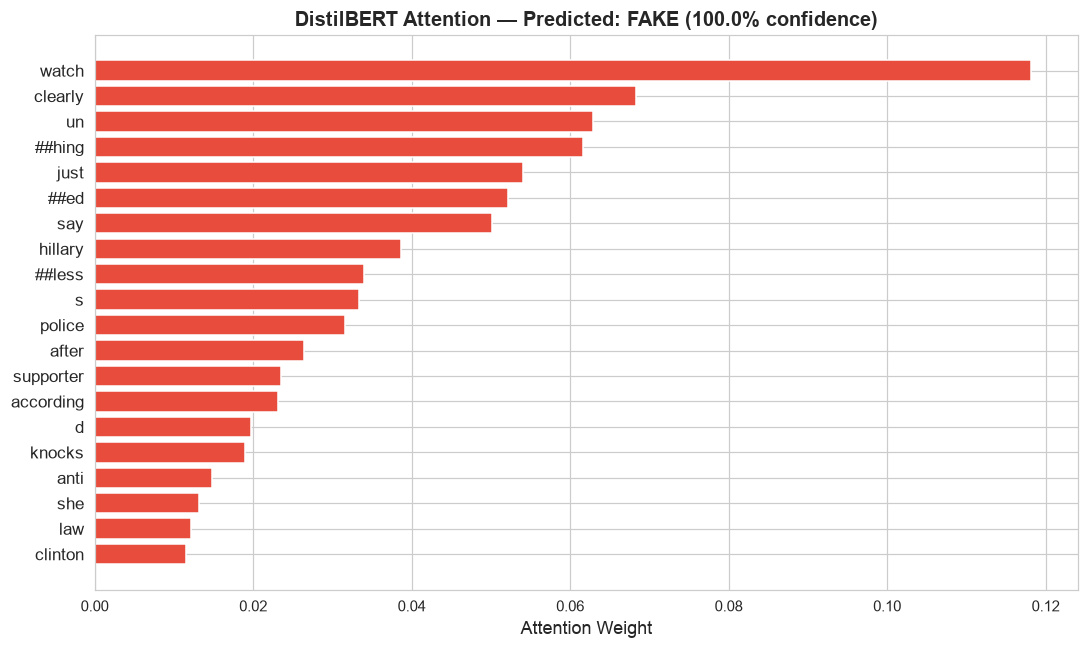

In [20]:
# ==============================================================================
# DistilBERT Attention Visualization — "Why did the model decide?"
# ==============================================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer

# 1. Load config and explicitly force eager attention + output_attentions
BERT_DIR = "../models/distilbert_fake_news"

tokenizer = AutoTokenizer.from_pretrained(BERT_DIR)

# Configure the model to materialize full attention matrices
config = AutoConfig.from_pretrained(BERT_DIR)
config.output_attentions = True
config.attn_implementation = "eager"

model = AutoModelForSequenceClassification.from_pretrained(
    BERT_DIR,
    config=config,
    attn_implementation="eager"
)

# Auto-detect hardware: Apple Silicon MPS -> CUDA GPU -> CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()
print(f"✅ DistilBERT loaded with eager attention on {device}")


# 2. Define the visualize_attention function
def visualize_attention(text, model, tokenizer, layer=-1, top_k=20):
    """
    Extract and visualize attention weights from DistilBERT.
    Shows which words the model focused on most to make its decision.
    """
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Safety check
    if not outputs.attentions or len(outputs.attentions) == 0:
        print("❌ Error: Attention weights were not returned. Ensure config.output_attentions=True.")
        return

    # Get attention from the specified layer (last layer by default: -1)
    attention = outputs.attentions[layer]
    # Average over all 12 attention heads -> shape: (seq_len, seq_len)
    avg_attention = attention.mean(dim=1).squeeze(0).cpu().numpy()

    # CLS token's attention to all other tokens (row 0)
    cls_attention = avg_attention[0]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

    # Remove special tokens and padding
    valid = [
        (tok, att) for tok, att in zip(tokens, cls_attention)
        if tok not in ["[CLS]", "[SEP]", "[PAD]"]
    ]

    if not valid:
        print("No valid tokens found.")
        return

    words, scores = zip(*valid)

    # Prediction label & probabilities
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_label = "REAL" if np.argmax(probs) == 1 else "FAKE"

    # Select top_k tokens by attention score
    k = min(top_k, len(words))
    sorted_indices = np.argsort(scores)[::-1][:k]
    top_words = [words[i] for i in sorted_indices]
    top_scores = [scores[i] for i in sorted_indices]

    # Plot horizontal bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#e74c3c" if pred_label == "FAKE" else "#27ae60"] * k
    ax.barh(range(k), top_scores[::-1], color=colors[::-1])
    ax.set_yticks(range(k))
    ax.set_yticklabels(top_words[::-1], fontsize=11)
    ax.set_xlabel("Attention Weight", fontsize=12)
    ax.set_title(
        f"DistilBERT Attention — Predicted: {pred_label} ({probs.max()*100:.1f}% confidence)",
        fontsize=13,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/attention_visualization.png", dpi=150)
    plt.show()


# 3. Test on article from X_test
test_index = 0
text = X_test.iloc[test_index]
actual = y_test.iloc[test_index]

print("=" * 70)
print(f"Article #{test_index} (Actual: {'REAL' if actual == 1 else 'FAKE'})")
print(text[:300], "...\n")
print("=" * 70)

visualize_attention(text, model, tokenizer)